Pour un Call ($C$) et un Put ($P$) européens, les formules de Black-Scholes sont :$$C = S_t N(d_1) - K e^{-r T} N(d_2)$$$$P = K e^{-r T} N(-d_2) - S_t N(-d_1)$$Où :$$d_1 = \frac{\ln(S_t / K) + (r + \sigma^2 / 2) T}{\sigma \sqrt{T}}$$$$d_2 = d_1 - \sigma \sqrt{T}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def black_scholes_params(S, K, T, r, sigma):
    """Calcule d1 et d2 pour éviter la redondance."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_price(S, K, T, r, sigma, option_type="call"):
    """Pricing analytique d'un Call ou Put européen."""
    d1, d2 = black_scholes_params(S, K, T, r, sigma)
    if option_type.lower() == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type.lower() == "put":
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("option_type doit être 'call' ou 'put'")

2. Le calcul analytique des Grecs (Delta et Gamma)Le Delta ($\Delta$) mesure la sensibilité du prix de l'option par rapport au cours du sous-jacent. Le Gamma ($\Gamma$) mesure la sensibilité du Delta par rapport à ce même cours.$$\Delta_{\text{Call}} = N(d_1), \quad \Delta_{\text{Put}} = N(d_1) - 1$$$$\Gamma = \frac{N'(d_1)}{S_t \sigma \sqrt{T}} \quad \text{où } N'(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$$

In [2]:
def bs_delta(S, K, T, r, sigma, option_type="call"):
    d1, _ = black_scholes_params(S, K, T, r, sigma)
    if option_type.lower() == "call":
        return norm.cdf(d1)
    elif option_type.lower() == "put":
        return norm.cdf(d1) - 1

def bs_gamma(S, K, T, r, sigma):
    d1, _ = black_scholes_params(S, K, T, r, sigma)
    # norm.pdf(d1) représente la dérivée de la distribution normale standard N'(d1)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

3. Visualisation de la convergence du Delta à l'échéanceCode ce script pour générer un graphique montrant comment le Delta d'un Call passe d'une courbe lisse à une fonction de Heaviside (0 ou 1) quand le temps restant $T$ tend vers 0. C'est ce qui illustre le risque de couverture dynamique (gamma risk).

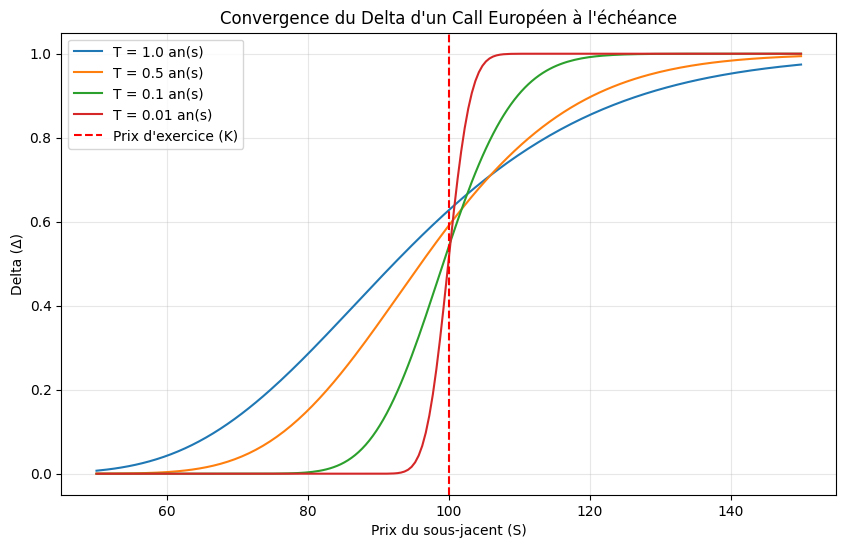

In [3]:
def plot_delta_convergence():
    S_range = np.linspace(50, 150, 200)
    K = 100
    r = 0.05
    sigma = 0.25
    times_to_expiry = [1.0, 0.5, 0.1, 0.01] # De 1 an à 3 jours

    plt.figure(figsize=(10, 6))
    for T in times_to_expiry:
        deltas = [bs_delta(S, K, T, r, sigma, "call") for S in S_range]
        plt.plot(S_range, deltas, label=f"T = {T} an(s)")

    plt.axvline(x=K, color="red", linestyle="--", label="Prix d'exercice (K)")
    plt.title("Convergence du Delta d'un Call Européen à l'échéance")
    plt.xlabel("Prix du sous-jacent (S)")
    plt.ylabel("Delta (Δ)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Lance le graphique pour vérifier que tout fonctionne
plot_delta_convergence()